# Test Single Sample — Diffusion Model Evaluation

This notebook loads the trained diffusion model checkpoint (`saved_models/diffusion_model.pt`)
and runs the **reverse process**: starting from pure Gaussian noise, it
iteratively denoises step by step (T -> 0) until a final generated image
appears,


In [20]:
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.append('/content/drive/My Drive/assignment5')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
CHECKPOINT_PATH = '/content/drive/My Drive/assignment5/saved_models/diffusion_model.pt'

In [22]:

import sys
sys.path.append('.')


In [23]:
import torch
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

# UNet and GaussianDiffusion both live inside rollNumber_05.py
from MSDS25051_05 import UNet, GaussianDiffusion, denormalize

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', device)


Using device: cuda


In [24]:
CHECKPOINT_PATH = '/content/drive/My Drive/assignment5/outputs/diffusion_model.pt'

checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
config = checkpoint['config']
print('Model was trained on classes:', config['classes'])
print('Config:', config)

model = UNet(base_channels=config['base_channels']).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

diffusion = GaussianDiffusion(
    timesteps=config['timesteps'],
    beta_start=config['beta_start'],
    beta_end=config['beta_end'],
    device=device,
)
print('Model and diffusion process loaded successfully.')


Model was trained on classes: ['Bear', 'Lion', 'Tiger', 'Deer', 'Bird']
Config: {'image_size': 64, 'timesteps': 1000, 'beta_start': 0.0001, 'beta_end': 0.02, 'base_channels': 64, 'classes': ['Bear', 'Lion', 'Tiger', 'Deer', 'Bird']}
Model and diffusion process loaded successfully.


## 1. Generate a single image from random noise

This is the core "test function": we sample `x_T ~ N(0, I)` and run the
full reverse diffusion loop down to `x_0`.

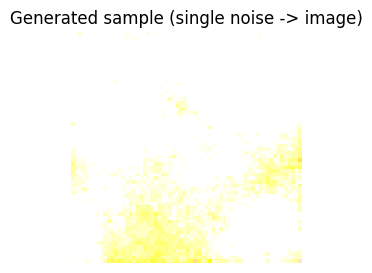

In [25]:
@torch.no_grad()
def generate_image_from_noise(model, diffusion, image_size, device, noise=None):
    """Accepts (optional) noise and returns a generated image tensor in [0,1]."""
    if noise is None:
        noise = torch.randn(1, 3, image_size, image_size, device=device)
    generated = diffusion.sample_from_given_noise(model, noise)
    return denormalize(generated)[0].cpu()

image_size = config['image_size']
generated = generate_image_from_noise(model, diffusion, image_size, device)

plt.figure(figsize=(3, 3))
plt.imshow(generated.permute(1, 2, 0).numpy())
plt.axis('off')
plt.title('Generated sample (single noise -> image)')
plt.show()


## 2. Visualize the full reverse trajectory (noise -> image)

This mirrors Figure 1 from the assignment, but in reverse: showing the
image emerging from noise over the denoising steps.

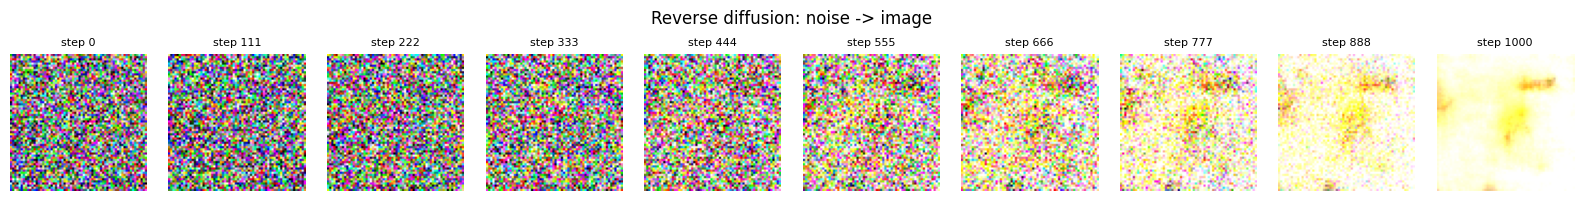

In [26]:
@torch.no_grad()
def generate_with_trajectory(model, diffusion, image_size, device, num_shown=10):
    noise = torch.randn(1, 3, image_size, image_size, device=device)
    final_img, all_steps = diffusion.sample_from_given_noise(model, noise, return_all_steps=True)

    total_steps = len(all_steps)
    idxs = torch.linspace(0, total_steps - 1, num_shown).long().tolist()
    chosen = [all_steps[i] for i in idxs]
    return chosen, idxs

chosen_steps, idxs = generate_with_trajectory(model, diffusion, image_size, device, num_shown=10)

fig, axes = plt.subplots(1, len(chosen_steps), figsize=(len(chosen_steps) * 1.6, 2))
for ax, step_img, step_idx in zip(axes, chosen_steps, idxs):
    vis = denormalize(step_img[0]).permute(1, 2, 0).clamp(0, 1).numpy()
    ax.imshow(vis)
    ax.set_title(f'step {step_idx}', fontsize=8)
    ax.axis('off')
fig.suptitle('Reverse diffusion: noise -> image')
plt.tight_layout()
plt.show()


## 3. Generate a batch/grid of samples

Useful for the report: shows overall sample diversity and quality.

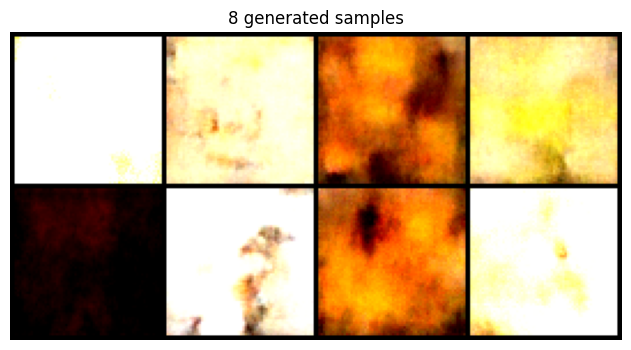

In [27]:
NUM_SAMPLES = 8

@torch.no_grad()
def generate_batch(model, diffusion, image_size, num_samples, device):
    shape = (num_samples, 3, image_size, image_size)
    samples = diffusion.p_sample_loop(model, shape, device)
    return denormalize(samples).cpu()

batch = generate_batch(model, diffusion, image_size, NUM_SAMPLES, device)
grid = make_grid(batch, nrow=4)

plt.figure(figsize=(8, 4))
plt.imshow(grid.permute(1, 2, 0).numpy())
plt.axis('off')
plt.title(f'{NUM_SAMPLES} generated samples')
plt.show()


## 4. Provide own custom noise tensor

Pass any noise tensor of shape `(1, 3, image_size, image_size)`
to `generate_image_from_noise` — for example a fixed seed, to get
reproducible results, or noise saved from a previous run.

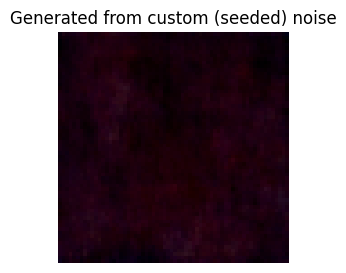

In [28]:
torch.manual_seed(123)
custom_noise = torch.randn(1, 3, image_size, image_size, device=device)

custom_generated = generate_image_from_noise(model, diffusion, image_size, device, noise=custom_noise)

plt.figure(figsize=(3, 3))
plt.imshow(custom_generated.permute(1, 2, 0).numpy())
plt.axis('off')
plt.title('Generated from custom (seeded) noise')
plt.show()
